<h1 style="text-align: center;"> Data Preprocessing & Feature Engineering </h1>
<h4 style="text-align: center;">  From Raw Data to Model-Ready Features </h4>

Missing data refers to the **absence of values** in a dataset.  
In machine learning, most algorithms cannot handle missing values directly and require complete datasets for training.  

### Why is handling missing data important?  
- Prevents bias in model training  
- Maintains dataset integrity  
- Ensures compatibility with ML algorithms  
- Improves model performance and reliability  

## Types of Missing Data  

###  1. MCAR – Missing Completely At Random
- **Meaning:** The fact that a value is missing has nothing to do with any other variable in the dataset or the missing value itself.  
- **Think of it as:** Pure chance.  
- **Example:**  
  - In a survey, some responses are lost because the data entry person accidentally skipped them.  
  - A sensor randomly fails to record the temperature at certain times due to random glitches.  
- **Impact:**  
  - If data is MCAR, the missing values don’t bias the dataset — analysis remains valid if you just drop them.

###  2. MAR – Missing At Random
- **Meaning:** The missingness is related to **other observed data**, but **not** to the value that is missing itself.  
- **Think of it as:** Missing depends on something you know.  
- **Example:**  
  - Income is missing more often for younger people (observed: age) but **not because of the income itself**.  
  - People with higher education (observed: education level) may skip answering certain health questions, but missingness isn’t directly tied to the health outcome.  
- **Impact:**  
  - We can model the missingness using the observed variables (e.g., impute income based on age and job).  
  - Common assumption in most imputation methods.

###  3. MNAR – Missing Not At Random
- **Meaning:** The missingness is directly related to the value that is missing.  
- **Think of it as:** The reason it’s missing is *inside the missing value itself*.  
- **Example:**  
  - People with **very high income** don’t want to disclose it → missingness depends on the actual (high) income.  
  - Patients with **severe depression** are less likely to answer mental health questionnaires.  
- **Impact:**  
  - This is the hardest case — ignoring or simply imputing can bias results.  
  - Requires advanced statistical models or external data to handle.

### 🔑 Summary in Plain Words
- **MCAR:** Missingness = pure accident.  
- **MAR:** Missingness = depends on *other data we have*.  
- **MNAR:** Missingness = depends on the *hidden, missing value itself*.  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import plotly.express as px

# Set Float precision
pd.options.display.float_format = '{:,.3f}'.format
# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
df = pd.read_csv('../data/cleaned_data.csv')
df.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,11.438,998.000,58.160,5.000,1.750,Maruti,Wagon
1,Pune,2015,41000,Diesel,Manual,First,19.670,"1,582.000",126.200,5.000,12.500,Hyundai,Creta
2,Chennai,2011,46000,Petrol,Manual,First,18.200,"1,199.000",88.700,5.000,4.500,Honda,Jazz
3,Chennai,2012,87000,Diesel,Manual,First,20.770,"1,248.000",88.760,7.000,6.000,Maruti,Ertiga
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.200,"1,968.000",140.800,5.000,17.740,Audi,A4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6015 entries, 0 to 6014
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           6015 non-null   object 
 1   Year               6015 non-null   int64  
 2   Kilometers_Driven  6015 non-null   int64  
 3   Fuel_Type          6015 non-null   object 
 4   Transmission       6015 non-null   object 
 5   Owner_Type         6015 non-null   object 
 6   Mileage            5945 non-null   float64
 7   Engine             5979 non-null   float64
 8   Power              5873 non-null   float64
 9   Seats              5973 non-null   float64
 10  Price              6015 non-null   float64
 11  Brand              6015 non-null   object 
 12  Model              6015 non-null   object 
dtypes: float64(5), int64(2), object(6)
memory usage: 611.0+ KB


In [4]:
df['Seats'] = df['Seats'].astype('category')

In [5]:
df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Price
count,"6,015.000","6,015.000","5,945.000","5,979.000","5,873.000","6,015.000"
mean,"2,013.358","57,670.792",18.195,"1,619.955",113.128,9.425
std,3.270,"37,870.190",4.152,598.896,53.507,10.905
min,"1,998.000",171.000,5.676,72.000,34.200,0.440
25%,"2,011.000","34,000.000",15.150,"1,198.000",75.000,3.500
50%,"2,014.000","53,000.000",18.120,"1,493.000",97.700,5.630
75%,"2,016.000","73,000.000",21.030,"1,984.000",138.100,9.950
max,"2,019.000","775,000.000",28.400,"5,998.000",552.000,100.000


In [6]:
# First, Split the data into train and test sets
from sklearn.model_selection import train_test_split

X = df.drop(['Price'] , axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Missing Values

In [7]:
df.isna().sum()

Location               0
Year                   0
Kilometers_Driven      0
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage               70
Engine                36
Power                142
Seats                 42
Price                  0
Brand                  0
Model                  0
dtype: int64

In [8]:
df.isna().mean() * 100

Location            0.000
Year                0.000
Kilometers_Driven   0.000
Fuel_Type           0.000
Transmission        0.000
Owner_Type          0.000
Mileage             1.164
Engine              0.599
Power               2.361
Seats               0.698
Price               0.000
Brand               0.000
Model               0.000
dtype: float64

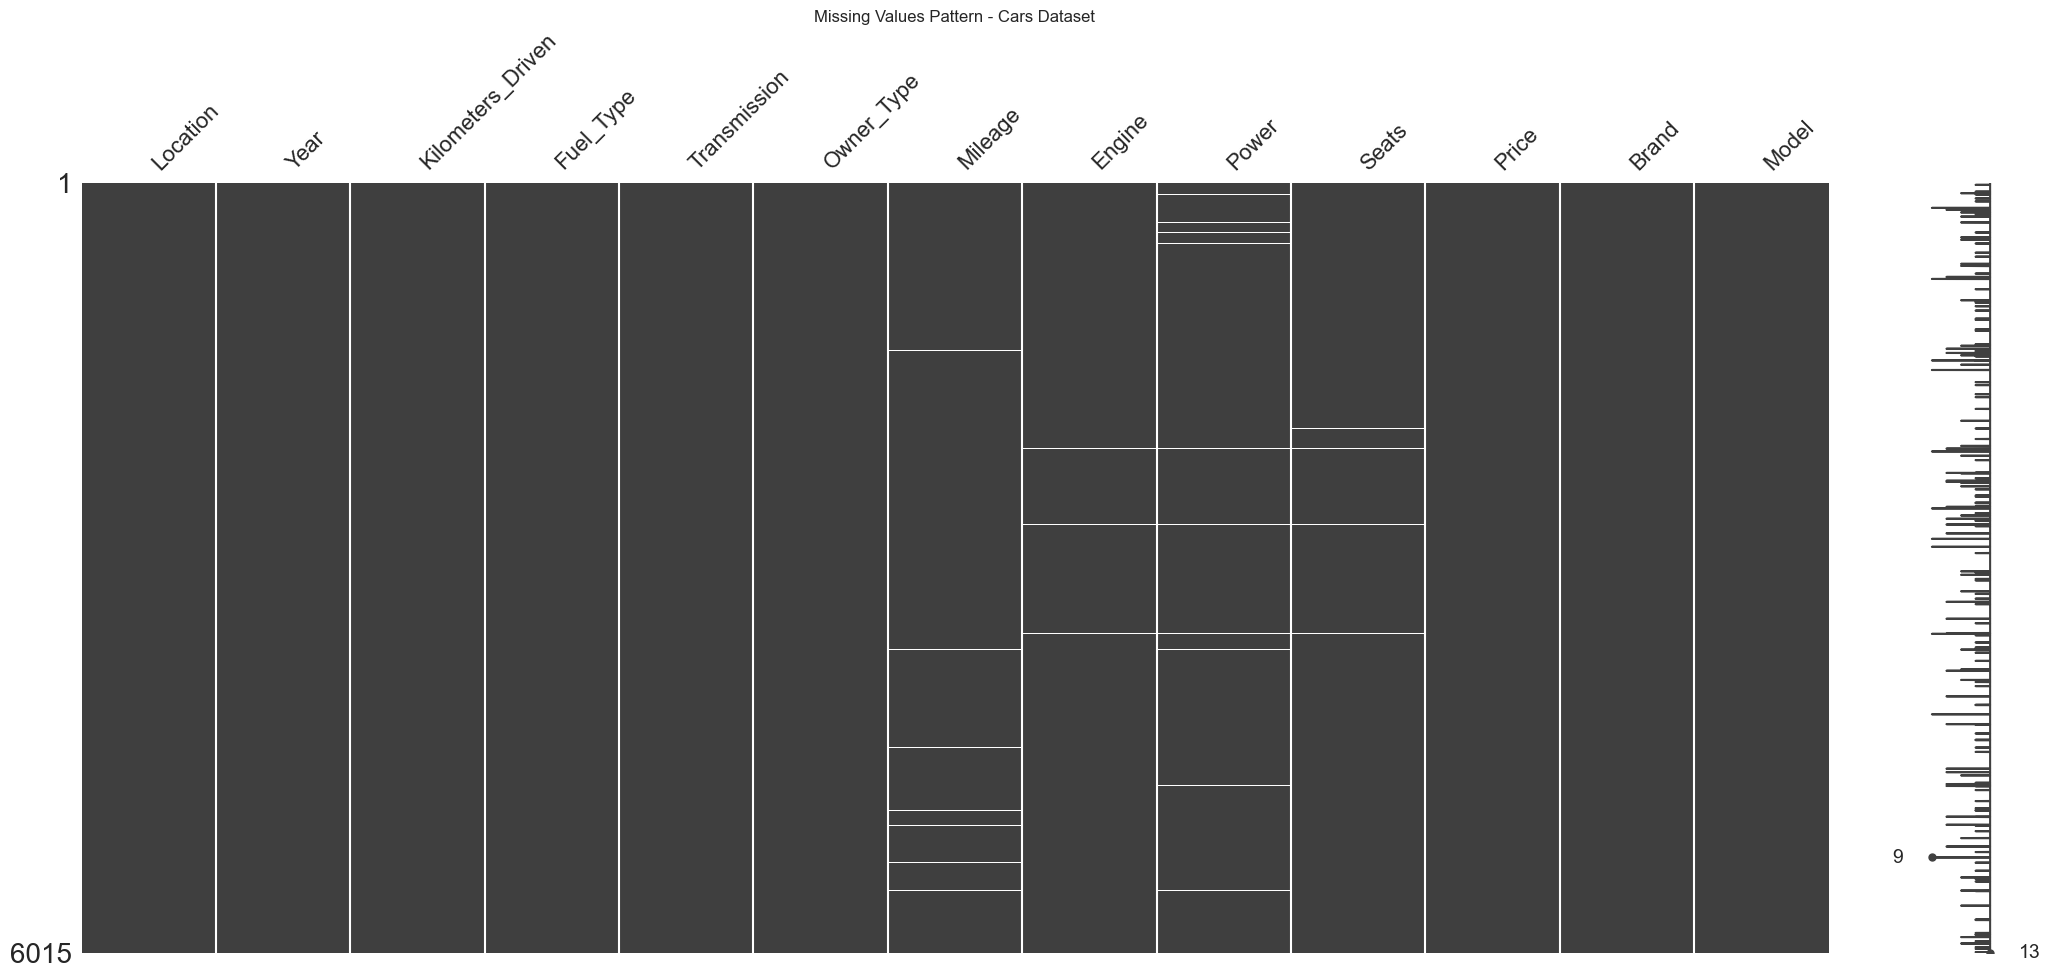

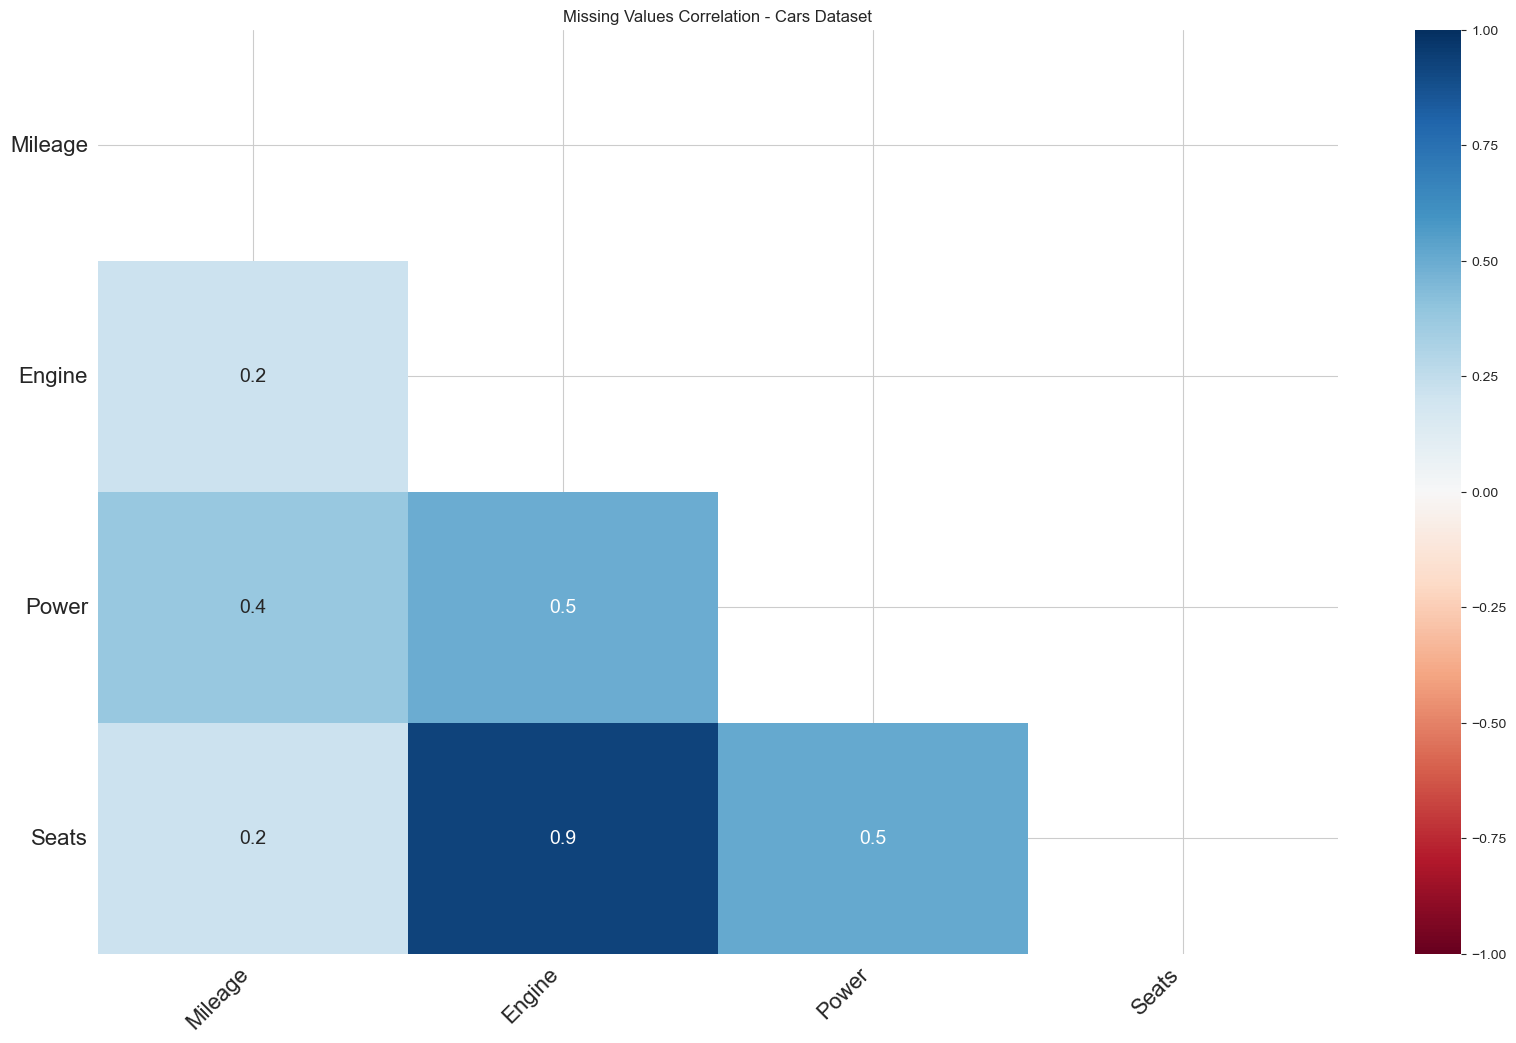

In [9]:
# Check pattern of missingness
import missingno as msno

# Matrix view of missing values
msno.matrix(df)
plt.title('Missing Values Pattern - Cars Dataset')
plt.show()

# Heatmap of missing value correlation
msno.heatmap(df)
plt.title('Missing Values Correlation - Cars Dataset')
plt.show()

## Complete Case Analysis (Drop)

In [10]:
# Complete case analysis - dropping all rows with any missing values
df_complete = df.dropna()
print(f"Original cars dataset shape: {df.shape}")
print(f"After complete case analysis: {df_complete.shape}")
print(f"Percentage of data lost: {(1 - len(df_complete)/len(df)) * 100:.2f}%")

Original cars dataset shape: (6015, 13)
After complete case analysis: (5841, 13)
Percentage of data lost: 2.89%


In [11]:
# Dropping missing rows for specific columns using subset
df_dropped = df.dropna(subset=['Engine','Seats'])
print(f"After dropping specific rows: {df_dropped.shape}")

After dropping specific rows: (5973, 13)


## Simple Imputation


The **SimpleImputer** is the most straightforward way to handle missing values.  
It replaces missing entries with a fixed statistic:

- **Numerical columns** → median (robust against outliers compared to mean)  
- **Categorical columns** → most frequent value (the mode)

**Why use it?**
- Very fast and easy to apply  
- Works well when missingness is small and data distribution is not too complex  
- Provides a strong baseline for more advanced methods

⚠️ Limitation: It ignores relationships between features.  
For example, two cars with similar attributes could get very different imputed values just because of the global median.


In [12]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# separate numeric and categorical columns
num_cols = X_train.select_dtypes(include= np.number).columns
cat_cols = X_train.select_dtypes(exclude= np.number).columns

# define imputers
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

# build column transformer
preprocessor = ColumnTransformer(transformers=[
                                                ("num", num_imputer, num_cols),
                                                ("cat", cat_imputer, cat_cols)
                                                ], verbose_feature_names_out=False  # 👈 disables prefixes
                              ).set_output(transform="pandas")

# fit/transform
X_train_imputed = preprocessor.fit_transform(X_train)
X_test_imputed  = preprocessor.transform(X_test)

X_train_imputed.head()


,Year,Kilometers_Driven,Mileage,Engine,Power,Location,Fuel_Type,Transmission,Owner_Type,Seats,Brand,Model
5639,"2,006.000","155,000.000",15.400,"1,590.000",94.000,Pune,Petrol,Manual,Third,5.000,Maruti,Baleno
2303,"2,006.000","109,000.000",16.900,"1,497.000",100.000,Chennai,Petrol,Manual,First,5.000,Honda,City
2617,"2,008.000","128,813.000",19.090,"1,396.000",69.000,Jaipur,Diesel,Manual,First,5.000,Tata,Indigo
1397,"2,016.000","35,659.000",15.970,"2,993.000",258.000,Kochi,Diesel,Automatic,First,7.000,BMW,X5
3703,"2,013.000","51,000.000",19.080,"1,582.000",126.320,Delhi,Diesel,Automatic,First,5.000,Hyundai,Verna


In [13]:
preprocessor.named_transformers_['num'].statistics_

array([2.014e+03, 5.300e+04, 1.820e+01, 1.462e+03, 9.370e+01])

In [14]:
X_train_imputed.isna().sum().sum(), X_test_imputed.isna().sum().sum()

(np.int64(0), np.int64(0))

In [15]:
# Compare Engine, Mileage, Power, Seats before and after imputation
comparison_cols = ['Engine', 'Mileage', 'Power']

print('==== Before Imputation Summary Statistics ====')
display(X_train[comparison_cols].describe())

print('==== After Imputation Summary Statistics ====')
display(X_train_imputed[comparison_cols].describe())

==== Before Imputation Summary Statistics ====


,Engine,Mileage,Power
count,"4,781.000","4,761.000","4,702.000"
mean,"1,616.236",18.221,112.899
std,598.340,4.138,53.499
min,72.000,6.248,34.200
25%,"1,197.000",15.200,75.000
50%,"1,462.000",18.200,93.700
75%,"1,968.000",21.100,138.100
max,"5,998.000",28.400,552.000


==== After Imputation Summary Statistics ====


,Engine,Mileage,Power
count,"4,812.000","4,812.000","4,812.000"
mean,"1,615.243",18.220,112.460
std,596.537,4.116,52.962
min,72.000,6.248,34.200
25%,"1,197.000",15.260,78.000
50%,"1,462.000",18.200,93.700
75%,"1,968.000",20.920,138.030
max,"5,998.000",28.400,552.000


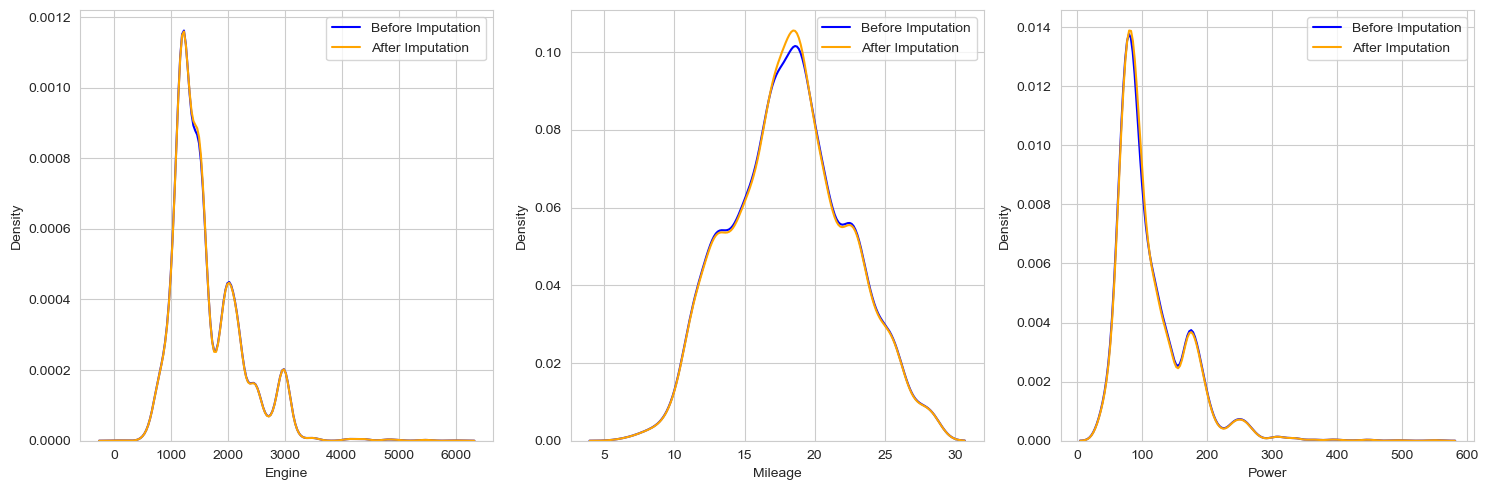

In [16]:
# Plot histograms before and after imputation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(comparison_cols):
    ax = axes[i]
    sns.kdeplot(X_train[col], ax=ax, label='Before Imputation', color='blue')
    sns.kdeplot(X_train_imputed[col], ax=ax, label='After Imputation', color='orange')
    ax.legend()

plt.tight_layout()
plt.show()

## KNN Imputer


The **KNNImputer** fills in missing values by looking at the "nearest neighbors":  
it finds the **k most similar rows** (based on other feature values) and uses their average to fill the gap.

- **Numerical columns** → replaced by the mean of the neighbors' values  
- **Categorical columns** → (still use a SimpleImputer, since KNN works only on numbers)

**Why use it?**
- Takes into account the relationships between features  
- Produces more realistic imputations when variables are correlated  
- Often improves model performance compared to simple global statistics

⚠️ Limitation:  
- Slower on large datasets (computes distances between rows)  
- Can be sensitive to irrelevant features or different scales (scaling/normalization is often recommended)


In [17]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.compose import ColumnTransformer

# split columns
          

# define imputers
num_imputer_knn = KNNImputer(n_neighbors=5)
cat_imputer = SimpleImputer(strategy="most_frequent")

# column transformer
preprocessor_knn = ColumnTransformer([
    ("num", num_imputer_knn, num_cols),
    ("cat", cat_imputer, cat_cols)
], verbose_feature_names_out=False  # 👈 disables prefixes
    ).set_output(transform="pandas")

# fit/transform
X_train_imputed = preprocessor_knn.fit_transform(X_train)
X_test_imputed  = preprocessor_knn.transform(X_test)

In [18]:
# check remaining NAs
X_train_imputed.isna().sum().sum(), X_test_imputed.isna().sum().sum()

(np.int64(0), np.int64(0))

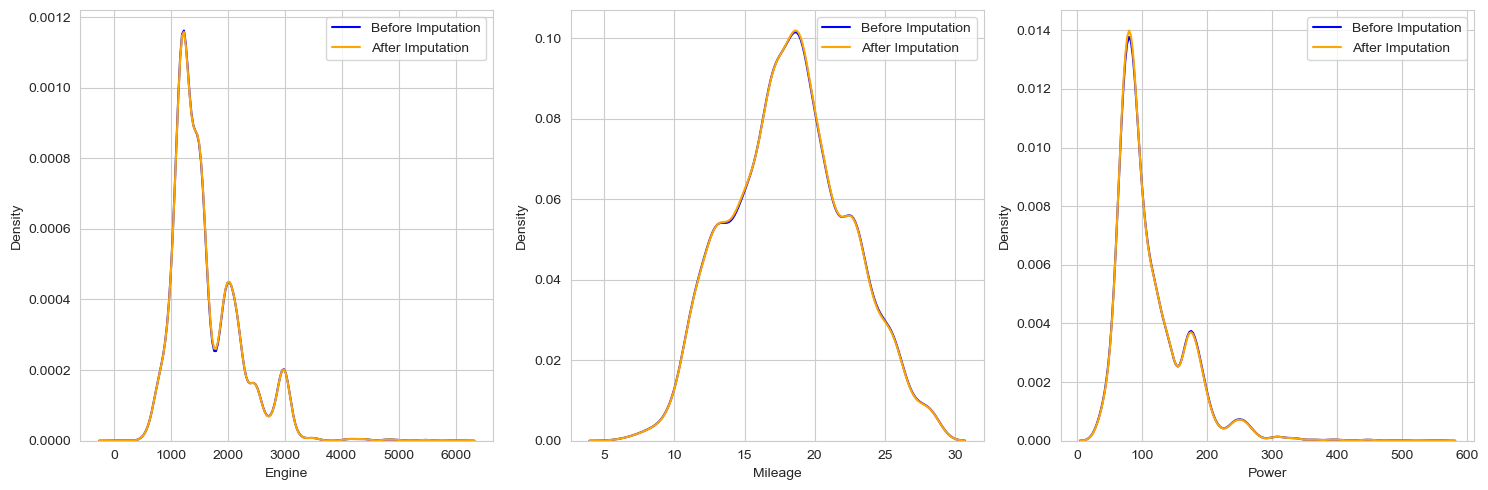

In [19]:
# Plot histograms before and after imputation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(comparison_cols):
    ax = axes[i]
    sns.kdeplot(X_train[col], ax=ax, label='Before Imputation', color='blue')
    sns.kdeplot(X_train_imputed[col], ax=ax, label='After Imputation', color='orange')
    ax.legend()

plt.tight_layout()
plt.show()

## Iterative Imputer (MICE-like)


The **IterativeImputer** is a more advanced imputation method.  
It models each feature with missing values as a function of the other features, and fills in missing data **iteratively** (round-robin).  
This idea is also called **MICE**: *Multiple Imputation by Chained Equations*.

### How it works
1. Start with initial guesses for missing values (e.g., column means).
2. Pick one column with missing values and predict it using all the other columns as inputs.
3. Replace the missing values with these predictions.
4. Move to the next column and repeat.
5. Iterate through all columns several times until results stabilize.

### Why use it?
- Captures **relationships between features** better than simple global statistics.
- Often produces **realistic imputations** when variables are correlated.
- Flexible: you can choose the estimator (e.g., `BayesianRidge`, `RandomForestRegressor`).

### Pros ✅
- Exploits correlations among features.
- More powerful than SimpleImputer or KNNImputer for complex datasets.

### Cons ⚠️
- **Slower** than SimpleImputer.
- Works only on **numerical features** (we still need a SimpleImputer for categoricals).
- May require tuning (`max_iter`, `estimator`) for stability/performance.

In [20]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge
from sklearn.compose import ColumnTransformer

# Split columns
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

# Define imputers
iterative_numeric = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42
)
cat_imputer = SimpleImputer(strategy="most_frequent")

# Combine in ColumnTransformer
preprocessor_iter = ColumnTransformer([
    ("num", iterative_numeric, num_cols),
    ("cat", cat_imputer, cat_cols)
], verbose_feature_names_out=False  # 👈 disables prefixes
).set_output(transform="pandas")

# Fit / transform
X_train_imputed = preprocessor_iter.fit_transform(X_train)
X_test_imputed  = preprocessor_iter.transform(X_test)

# Check remaining NaNs
X_train_imputed.isna().sum().sum(), X_test_imputed.isna().sum().sum()


(np.int64(0), np.int64(0))

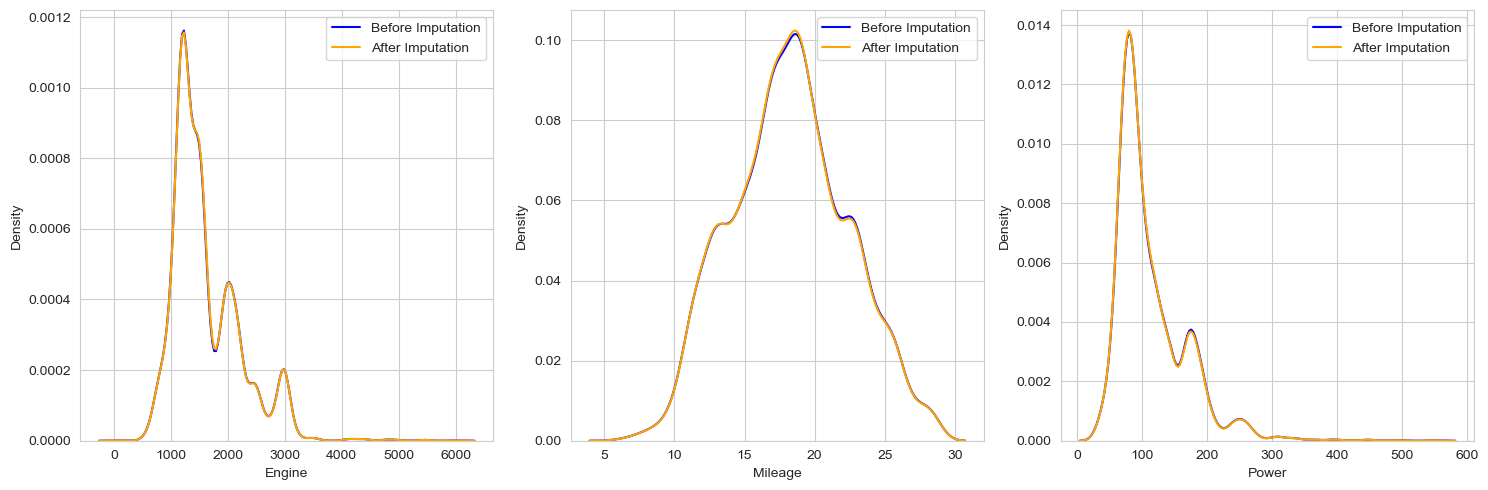

In [21]:
# Plot histograms before and after imputation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(comparison_cols):
    ax = axes[i]
    sns.kdeplot(X_train[col], ax=ax, label='Before Imputation', color='blue')
    sns.kdeplot(X_train_imputed[col], ax=ax, label='After Imputation', color='orange')
    ax.legend()

plt.tight_layout()
plt.show()

## Advanced Imputation

So far, we saw general-purpose imputers (Simple, KNN, Iterative).  
Now let’s go further and **use domain knowledge** to design *custom imputers*.

**Why useful?**  
This makes imputations more **context-aware**. Instead of using a single global statistic, it respects structure in the data (different models naturally have different specs).

### Simple Function

In [22]:
# Setup
group_cols = ['Brand', 'Model']
num_cols = ['Engine', 'Mileage', 'Power']
cat_cols = ['Seats']

# Compute group statistics
models_stats = {
    'median': X_train.groupby(group_cols)[num_cols].median(),
    'mode': X_train.groupby(group_cols)[cat_cols].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
}

# Compute overall statistics (fallbacks)
overall_stats = {
    'median': X_train[num_cols].median(),
    'mode': X_train[cat_cols].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
}

def impute_value(row, col, stat_type):
    """Generic imputation function for median/mode with group and global fallback."""
    if pd.notna(row[col]):
        return row[col]

    group_stat = models_stats[stat_type]
    overall_stat = overall_stats[stat_type]
    try:
        val = group_stat.loc[(row['Brand'], row['Model']), col]
        return overall_stat[col] if pd.isna(val) else val
    except KeyError:
        return overall_stat[col]



In [23]:
# Copy data
X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

# Apply median imputation for numeric columns
for col in num_cols:
    X_train_imputed[col] = X_train_imputed.apply(lambda row: impute_value(row, col, 'median'), axis=1)
    X_test_imputed[col] = X_test_imputed.apply(lambda row: impute_value(row, col, 'median'), axis=1)

# Apply mode imputation for categorical columns
for col in cat_cols:
    X_train_imputed[col] = X_train_imputed.apply(lambda row: impute_value(row, col, 'mode'), axis=1)
    X_test_imputed[col] = X_test_imputed.apply(lambda row: impute_value(row, col, 'mode'), axis=1)

In [24]:
X_train_imputed.isna().sum().sum(), X_test_imputed.isna().sum().sum()


(np.int64(0), np.int64(0))

### Class

In [25]:
class GroupwiseImputer:
    """
    Impute missing values using Brand+Model group statistics (median/mode),
    with global fallbacks for unseen combinations or NaNs.
    """

    def __init__(self, group_cols, num_cols=None, cat_cols=None):
        self.group_cols = group_cols
        self.num_cols = num_cols or []
        self.cat_cols = cat_cols or []
        self.models_stats_ = {}
        self.overall_stats_ = {}

    def fit(self, X):
        """Compute group-level and overall statistics from training data."""
        self.models_stats_ = {
            'median': X.groupby(self.group_cols)[self.num_cols].median(),
            'mode': X.groupby(self.group_cols)[self.cat_cols].agg(
                lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
            )
        }

        self.overall_stats_ = {
            'median': X[self.num_cols].median(),
            'mode': X[self.cat_cols].agg(
                lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
            )
        }
        return self

    def _impute_value(self, row, col, stat_type):
        """Helper: return imputed value for a single cell."""
        if pd.notna(row[col]):
            return row[col]

        group_stat = self.models_stats_[stat_type]
        overall_stat = self.overall_stats_[stat_type]

        try:
            val = group_stat.loc[tuple(row[self.group_cols]), col]
            return overall_stat[col] if pd.isna(val) else val
        except KeyError:
            # unseen (Brand, Model) group
            return overall_stat[col]

    def transform(self, X):
        """Impute missing values in numeric and categorical columns."""
        X = X.copy()
        for col in self.num_cols:
            X[col] = X.apply(self._impute_value, axis=1, col=col, stat_type='median')
        for col in self.cat_cols:
            X[col] = X.apply(self._impute_value, axis=1, col=col, stat_type='mode')
        return X

    def fit_transform(self, X):
        """Convenience method to fit and transform in one step."""
        return self.fit(X).transform(X)


In [26]:
group_cols = ['Brand', 'Model']
num_cols = ['Engine', 'Mileage', 'Power']
cat_cols = ['Seats']

imputer = GroupwiseImputer(group_cols, num_cols, cat_cols)

# Fit on training data
imputer.fit(X_train)

# Impute both training and test sets
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_imputed.isna().sum().sum(), X_test_imputed.isna().sum().sum()

(np.int64(0), np.int64(0))

### Sklearn-style class

In [27]:
from sklearn.base import BaseEstimator, TransformerMixin

class GroupwiseImputer(BaseEstimator, TransformerMixin):
    """
    Custom imputer that fills missing values using group-level (Brand, Model)
    median/mode statistics with global fallbacks.
    """

    def __init__(self, group_cols, num_cols=None, cat_cols=None):
        self.group_cols = group_cols
        self.num_cols = num_cols or []
        self.cat_cols = cat_cols or []
        self.models_stats_ = {}
        self.overall_stats_ = {}

    def fit(self, X, y=None):
        """Compute group and overall statistics on training data."""
        X = X.copy()

        # Compute per-group statistics
        self.models_stats_ = {
            'median': X.groupby(self.group_cols)[self.num_cols].median(),
            'mode': X.groupby(self.group_cols)[self.cat_cols].agg(
                lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
            )
        }

        # Compute overall fallback statistics
        self.overall_stats_ = {
            'median': X[self.num_cols].median(),
            'mode': X[self.cat_cols].agg(
                lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
            )
        }

        return self

    def _impute_value(self, row, col, stat_type):
        """Helper: impute a single cell based on group or fallback."""
        if pd.notna(row[col]):
            return row[col]

        group_stat = self.models_stats_[stat_type]
        overall_stat = self.overall_stats_[stat_type]

        try:
            val = group_stat.loc[tuple(row[self.group_cols]), col]
            return overall_stat[col] if pd.isna(val) else val
        except KeyError:
            # unseen (Brand, Model) combination
            return overall_stat[col]

    def transform(self, X):
        """Apply imputation to new data."""
        X = X.copy()
        for col in self.num_cols:
            X[col] = X.apply(self._impute_value, axis=1, col=col, stat_type='median')
        for col in self.cat_cols:
            X[col] = X.apply(self._impute_value, axis=1, col=col, stat_type='mode')
        return X


In [28]:
from sklearn.pipeline import Pipeline

group_cols = ['Brand', 'Model']
num_cols = ['Engine', 'Mileage', 'Power']
cat_cols = ['Seats']

# Create the imputer
imputer = GroupwiseImputer(group_cols, num_cols, cat_cols)

# Fit & transform
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Example: integrate into a pipeline
pipeline = Pipeline([
    ('group_imputer', GroupwiseImputer(group_cols, num_cols, cat_cols)),
    # ('scaler', StandardScaler()),   # you can chain others
    # ('model', RandomForestClassifier())
])

X_train_imputed.isna().sum().sum(), X_test_imputed.isna().sum().sum()

(np.int64(0), np.int64(0))

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define column sets
group_cols = ['Brand', 'Model']
num_cols = ['Engine', 'Mileage', 'Power']
cat_cols = ['Seats']

# 1️⃣ Apply GroupwiseImputer first
group_imputer = GroupwiseImputer(group_cols, num_cols, cat_cols)

# 2️⃣ Then define the rest of your transformations
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), group_cols + cat_cols)
])

# 3️⃣ Build your pipeline
pipe = Pipeline([
    ('group_imputer', group_imputer),
    ('preprocessor', preprocessor),
    # ('model', RandomForestClassifier())
])

# Fit the entire pipeline
pipe.fit(X_train, y_train)
X_test_transformed = pipe.transform(X_test)

X_train_imputed.isna().sum().sum(), X_test_imputed.isna().sum().sum()

(np.int64(0), np.int64(0))